---
title: Data Visualization Principles
subtitle: Advanced Principles of Data Visualization in Python
abstract: This notebook explores the advanced principles of data visualization in Python, focusing on best practices for creating clear, accurate, and effective visualizations. It covers the taxonomy of chart types, guidelines for selecting appropriate visualizations, and common pitfalls to avoid, such as misleading aesthetics, bad data representation, and perceptual errors. Practical examples and theoretical insights are provided to help users design visualizations that maximize clarity, precision, and impact while staying true to the data.
author:
  - name: Karol Flisikowski
    affiliations: 
      - Gdansk University of Technology
      - Chongqing Technology and Business University
    orcid: 0000-0002-4160-1297
    email: karol@ctbu.edu.cn
date: 2025-04-29
---

## In this chapter

We've already covered the basics of **creating** data visualizations with `pyplot` and `seaborn`.

In this chapter, we'll cover some **principles** of data visualization.

- **Taxonomy of chart types**: which chart to use, when?
- This is just a general guide - context always matters.
- **Principles** and **what to avoid**.

- Additional notes.

## Import relevant libraries

In [1]:
import seaborn as sns ### importing seaborn
import pandas as pd
import matplotlib.pyplot as plt ## just in case we need it

In [2]:
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

Data visualization is an essential skill for any data scientist. Choosing the right chart can make or break your analysis, helping your audience easily understand your insights.

**Understanding Data Types**

Before choosing a visualization, you need to identify the type of data you’re working with:

- Categorical data: Labels or groups (e.g. gender, product category)
- Numeric data: Continuous or discrete numbers (e.g. age, revenue)
- Time-series data: Data indexed by time (e.g. stock prices, temperature readings).
- Relational data: Data that shows relationships between variables (e.g. correlations).

## Taxonomy of plot types

### Rough guide: what plot to use, when?

| How many variables? | What kind of variable(s)? | Plot types | `seaborn` |
| ------------------- | ----------------------- | ---------- | --------------- |
| 1 | Continuous | Histogram | `seaborn.histplot`|
| 1 | Categorical | Count plot | `seaborn.countplot`|
| 2 | Cont. `x`, cont. `y` | Scatter, line | `seaborn.relplot`|
| 2 | Cat. `x`, cont. `y` | Bar, box, strip | `seaborn.catplot`|

### What about $>2$ variables?

It depends on the **type** of variables.

Rough guide:

- 2 continuous, 1 categorical: `seaborn.relplot` with `hue`
- 2 categorical, 1 continuous: `seaborn.catplot` with `hue`
- 3 continuous: `seaborn.relplot` with `size` or `hue`


## Principles, and *what to avoid*

- In this section, we'll propose and discuss possible *principles* behind building better visualizations.
- Many of these principles are *context-dependent*, and not without disagreement.

This section is closely modeled on [Chapter 1 of Kieran Healy's Data Visualization](https://socviz.co/lookatdata.html#why-look-at-data).

### What makes for a good visualization?

In [The visual display of quantitative information](https://www.edwardtufte.com/tufte/books_vdqi), Edward Tufte argues:

> Graphical excellence is the well-designed presentation of interesting data—a matter of substance, of statistics, and of design … [It] **consists of complex ideas communicated with clarity, precision, and efficiency.** … [It] is that which gives to the viewer the greatest number of ideas in the shortest time with the least ink in the smallest space … [It] is nearly always multivariate … And graphical excellence requires telling the truth about the data. (Tufte, 1983, p. 51).

This is true, but also very general––can we be more specific?

### Different kinds of bad?

The sociologist [Kieran Healy](https://kieranhealy.org/) points out that graphs can be "bad" in different ways.

1. *Aesthetic*: graph design is aesthetically unappealing.
2. *Substantive*: either the data or its presentation (or both) have fundamental problems. 
3. *Perceptual*: the graph is misleading because of how people perceive and process what they're looking at.

### Bad taste

Many graphs have aesthetic features that are *overly complex* given what they're trying to convey.

- **3D bar plots** despite no need for three dimensions. 
- Other aesthetic features like drop shadow. 

These features can needlesly "complexify" a graph, **making it harder to interpret**.

#### An overly complex graph

![title](img/life-expectancy.png)

#### Principle 1: Maximize data-to-ink ratio

- One suggestion is to **maximize the data-to-ink ratio**.
- Don't add aesthetic features unless they *convey information*.  

However...there's evidence that *some* aesthetically complex figures are *easier to remember*. So it depends!

### Bad data

No amount of elegant aesthetics can make up for bad data! 

Healy uses the [example of a graph from the New York Times](https://socviz.co/lookatdata.html#why-look-at-data). This graph is **misleading**:

- About the `x`-axis: implies same people at different time, when it's actually people of different *ages* at the same time.
- About the `y`-axis: implies yes/no question, when it's subsetting responses to a 10-point scale.

#### Principle 2: Be true to the data

Your visualization should represent *what the data measures*.

(This one's not really context-dependent! Always be true to the data.)

### Bad perception

Finally, graphs can be **misleading** because their aesthetics imply something *incorrect* about the data.

> Visualizations encode numbers in lines, shapes, and colors. That means that our interpretation of these encodings is partly conditional on how we perceive geometric shapes and relationships generally.  (Healy, [Data Visualization](https://socviz.co/lookatdata.html#why-look-at-data)).

#### Bar plots and the principle of proportional ink

A key *aesthetic feature* of bar plots is the **amount of ink** devoted to a bar.

- As viewers, our eyes measure the **relative difference** in how much space is devoted to each bar.
- Larger perceptual differences imply larger **magnitude differences**. 

This principle can be **violated** in several ways.

##### Truncated y-axis exaggerates differences

![title](img/average_hours.png)

[Source: Calling Bullshit](https://www.callingbullshit.org/tools/tools_misleading_axes.html)


##### Bars should be of equal width

![title](img/proportional_ink.png)

[Source: Witte and Witte](https://www.wiley.com/en-us/Statistics,+11th+Edition-p-9781119254515).

#### When *not* to start at zero?

- Bar plots should start at zero.
- But in many cases, starting at zero can actually be misleading. 
   - With line plots, the goal is to show the **relative difference in *position***.
   - With very large `y`-axis values, starting at zero can be confusing.

##### When relative change is what matters (pt. 1)

This graph shows changes in `temperature` (Celsius) over `Year`, and starts at 0.

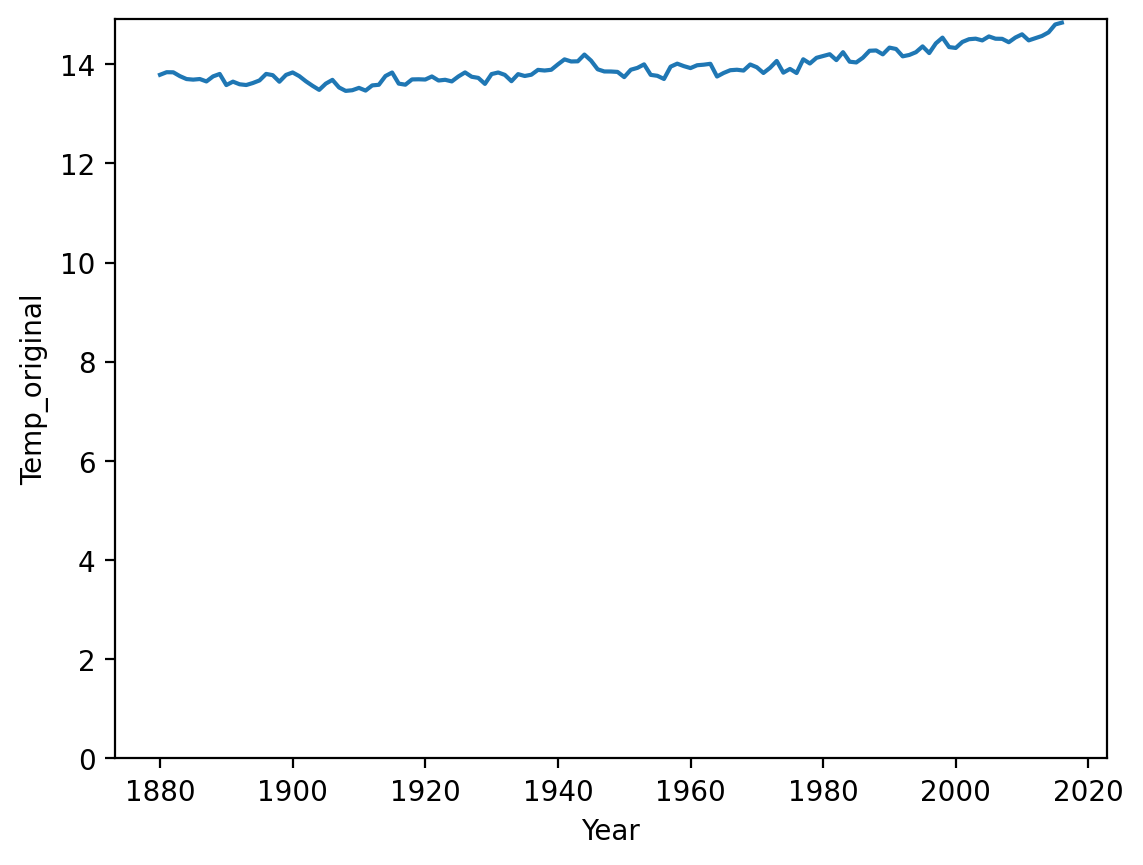

In [4]:
df_temp = pd.read_csv("data/viz/temp.csv")
sns.lineplot(data = df_temp, x = 'Year', y = 'Temp_original');
plt.ylim(0);

##### When relative change is what matters (pt. 2)

This graph shows changes in `temperature` (Celsius) over `Year`, but doesn't start at 0.

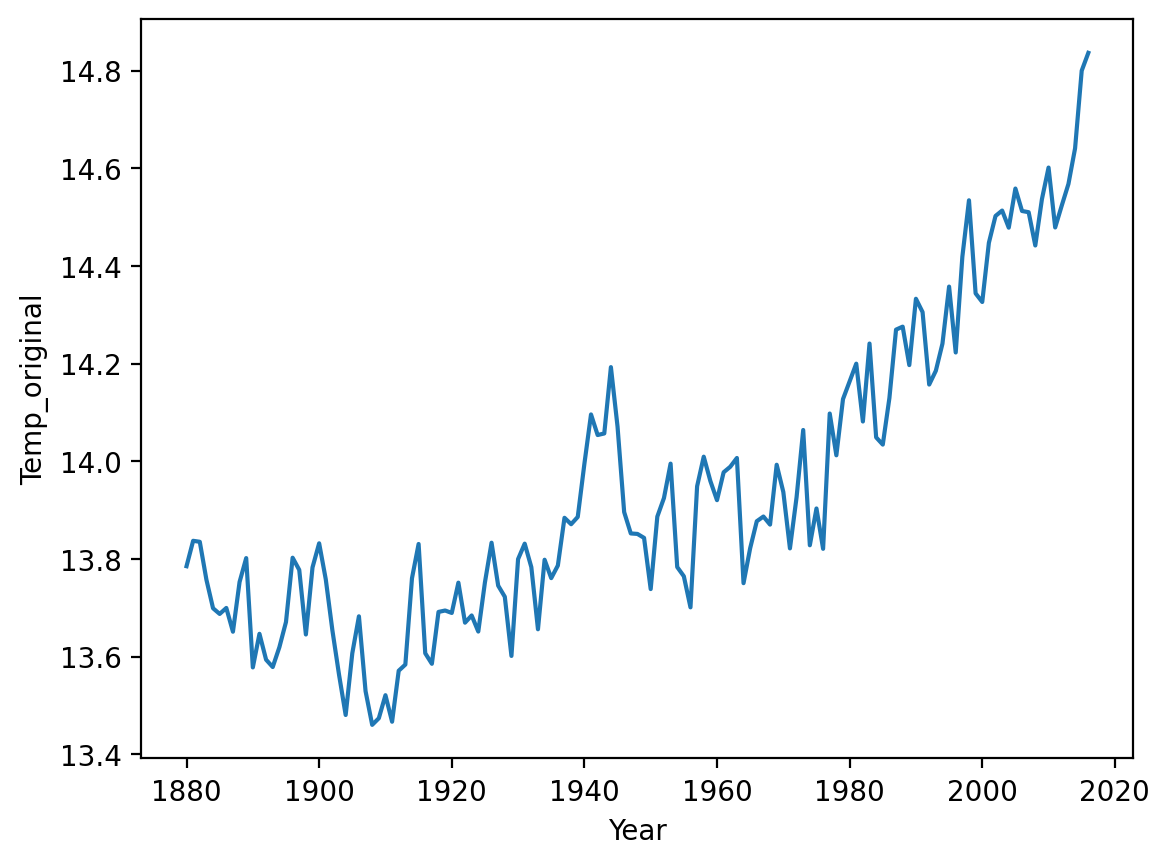

In [5]:
sns.lineplot(data = df_temp, x = 'Year', y = 'Temp_original');

### Summing up: principles and practice

We've discussed several principles (and corresponding *practices to avoid*):

1. **Principle 1**: Maximize data-ink ratio.
2. **Principle 2**: Be true to the data. 
3. **Principle 3**: Be true to what the *visual logic* of your graph implies.

## Additional considerations

Data visualization could make up an entire course (or [textbook](https://socviz.co/lookatdata.html#why-look-at-data)). 

But there are several other common issues to discuss:

- Should I show the *mean* (or median, etc.) or the *raw data*?
- Should I exclude outliers?
- Should I *transform* my data (e.g., to a log-scale)?

### Should I show the "raw data"?

All measures of **central tendency** (e.g., `mean`, `median`) are a *simplification* of our data.

- Thus, showing only the mean "hides" much of your data.  
- However, if the `mean` is what you *care* about, then the raw data can be overly complex.

Personally, I try to show the *raw data* where possible––along with the mean.

#### Showing *both* the summary and raw data

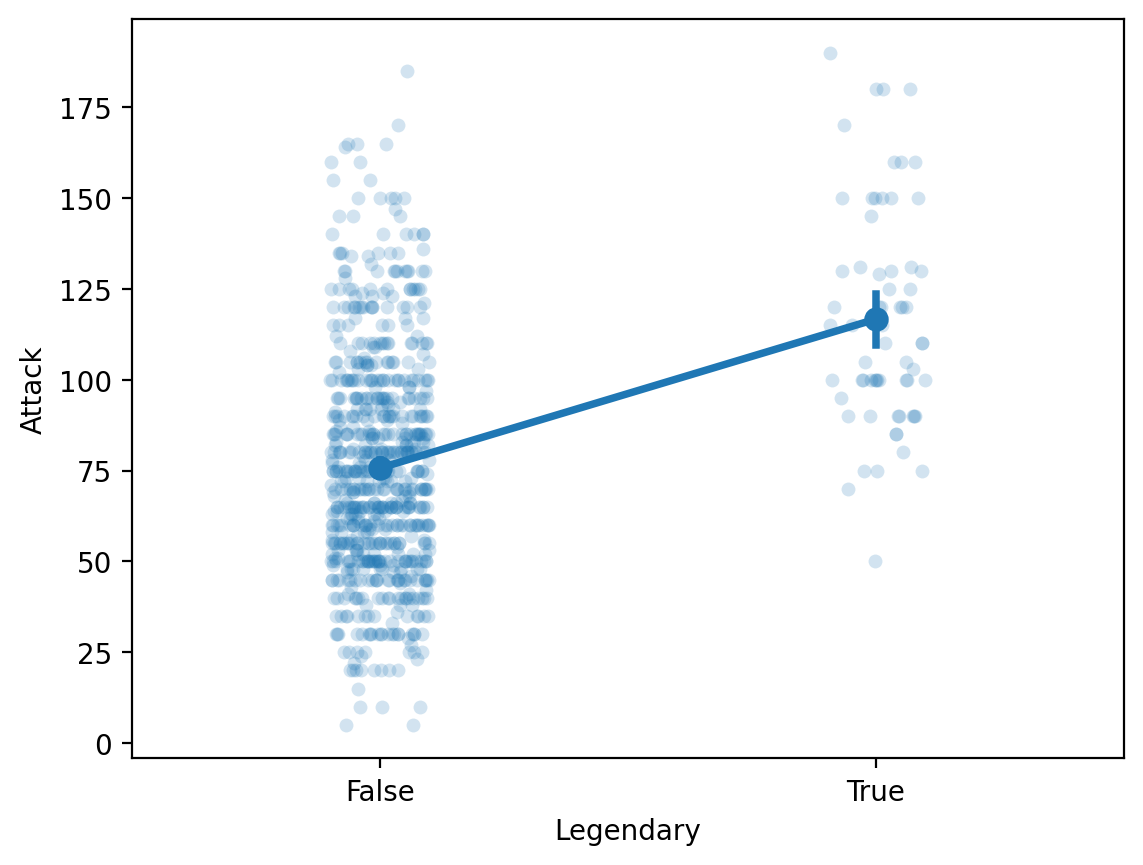

In [6]:
df_pokemon = pd.read_csv("data/pokemon.csv")
sns.stripplot(data = df_pokemon, x = "Legendary", y = "Attack", alpha = .2);
sns.pointplot(data = df_pokemon, x = "Legendary", y = "Attack");

### Should I exclude outliers?

> **Outliers** are data points that differ significantly from other points in a distribution.

Including outliers in a visualization can be confusing.

- They lengthen the axis despite being unrepresentative of the data.
- They can distract from the main point you want to convey.

**Should you remove them?**

#### Be transparent about exclusion

- This one is very context-dependent.  
- Personally, I *usually don't* exclude outliers. 
- But if you do exclude them, **be very clear about your decision**.
   - Ideally, this decision would be "pre-registered" ahead of time.
   
Next week, we'll discuss how to define/detect outliers using [**z-scores**](https://en.wikipedia.org/wiki/Standard_score).

### Should I transform my data?

Sometimes, the "raw" data is heavily skewed.

- A **log transform** can turn *right-skewed* data look more ["normal"](https://en.wikipedia.org/wiki/Normal_distribution). 
- When is this a good or bad idea?

#### Right-skewed data can be confusing

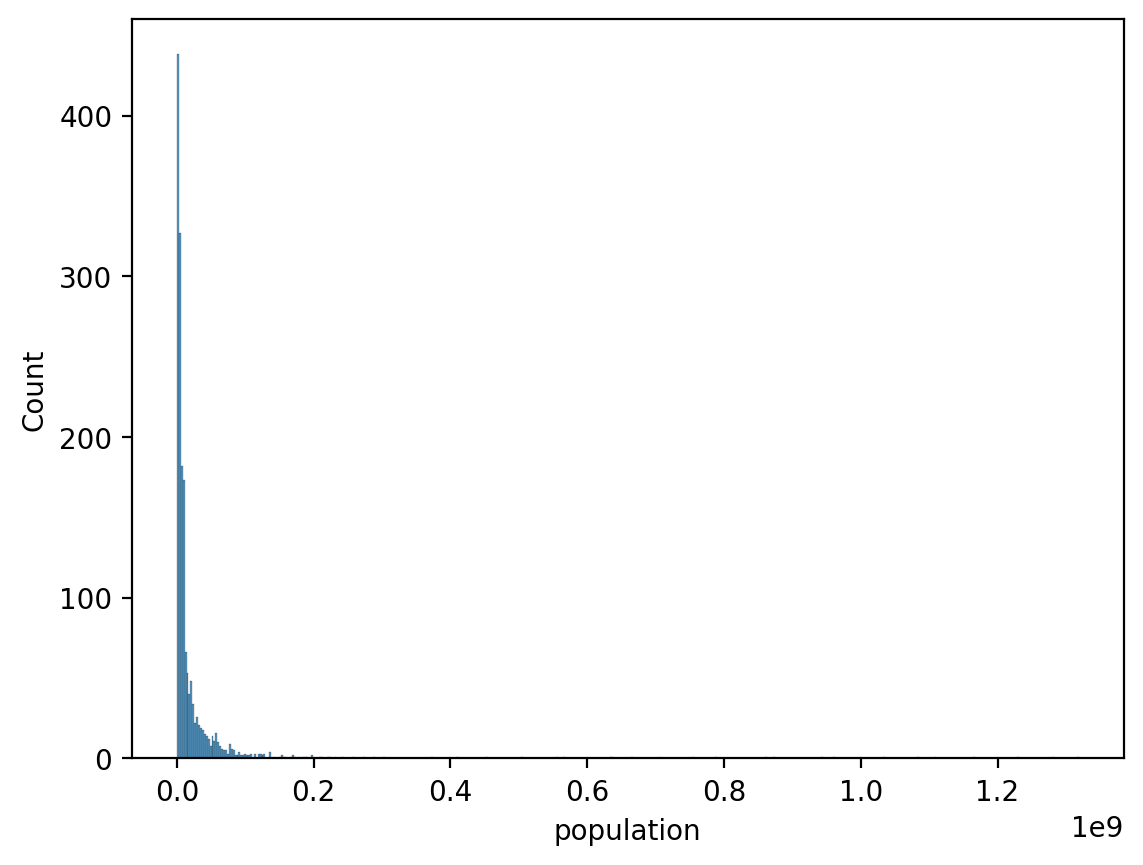

In [7]:
df_gapminder = pd.read_csv("data/viz/gapminder_full.csv")
sns.histplot(data = df_gapminder, x = 'population');

#### Log-transforms make it look more normal

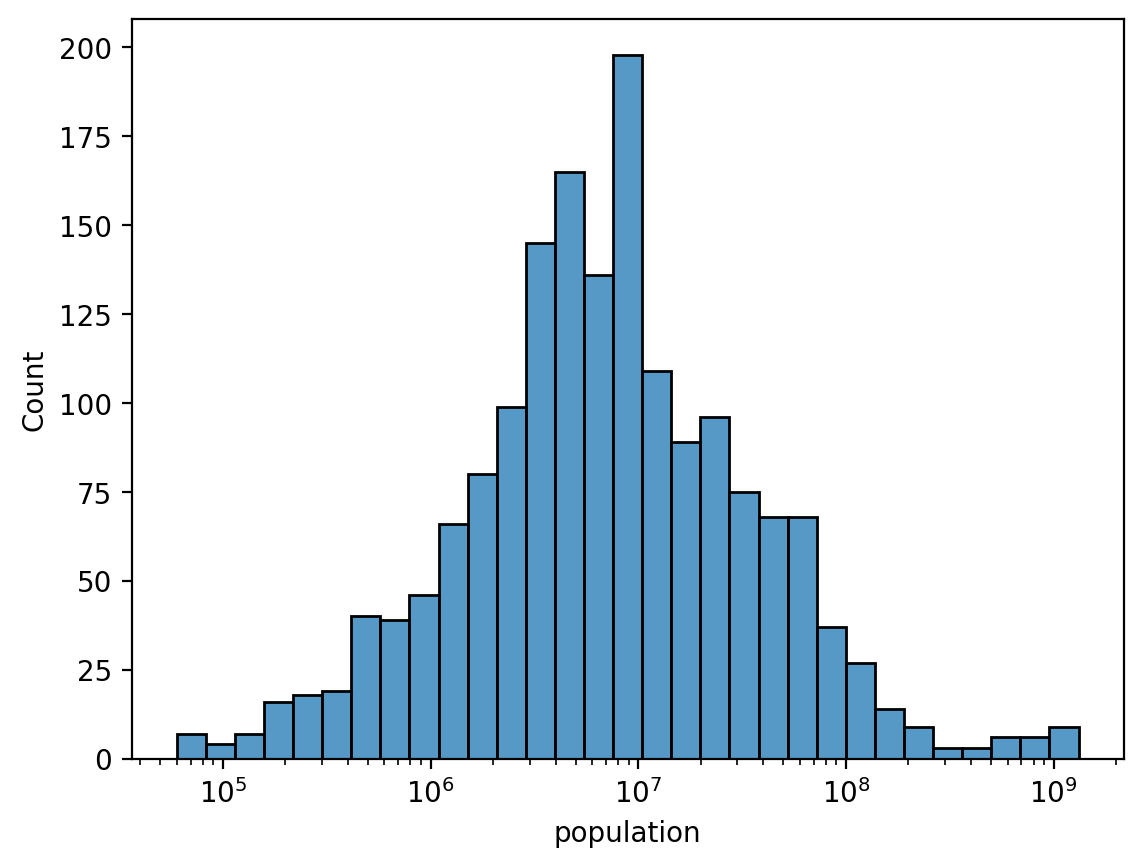

In [8]:
sns.histplot(data = df_gapminder, x = 'population', log_scale=True);

#### But what's "correct"?

Considerations to keep in mind:

- Is there reason to think that this variable **scales logarithmically**?
- Is there reason to think that this variable's relationship with *other variables* **scales logarithmically**?
- Will I be presenting this figure to an audience who **understands logarithmic scaling**? 

In terms of *interpretation*:

- A logarithmic scale implies **multiplicative/relative** changes.
- A linear scale implies **additive/absolute** changes.

## Summary

Data visualization is a *central* part of data analysis.

In this chapter, we focus on *packages* (`seaborn` and `pyplot`), as well as *rules* to keep in mind.

![title](img/chart.jpg)

For more information, see:

- [Calling Bullshit](https://www.callingbullshit.org/syllabus.html#Visual).

- [Data Visualization](https://socviz.co/lookatdata.html#why-look-at-data).

- [How to lie with statistics](https://en.wikipedia.org/wiki/How_to_Lie_with_Statistics).

- [Visually displaying quantitative information](https://www.edwardtufte.com/tufte/books_vdqi).

- [Python 4 Data Science - visualization](https://byuidatascience.github.io/python4ds/data-visualisation.html).